# EDA Final — Online Shoppers Purchasing Intention

**Objetivo principal:** comprender la estructura, calidad y comportamiento del dataset antes de iniciar el proceso de modelado.

**Variable objetivo:** `Revenue`

## Diccionario de columnas

- **Administrative**: cantidad de páginas administrativas visitadas.
- **Administrative_Duration**: tiempo total (en segundos) dedicado a páginas administrativas.
- **Informational**: cantidad de páginas informativas visitadas.
- **Informational_Duration**: tiempo dedicado a páginas informativas.
- **ProductRelated**: cantidad de páginas de productos visitadas.
- **ProductRelated_Duration**: tiempo total observando productos.
- **BounceRates**: porcentaje de sesiones en las que el usuario abandonó el sitio casi inmediatamente, sin interacción significativa.
- **ExitRates**: probabilidad de que una página sea la última visitada antes de abandonar el sitio.
- **PageValues**: valor económico esperado de una página en función de su contribución a conversiones.
- **SpecialDay**: cercanía de la sesión a una fecha comercial especial.
- **Month**: mes de la sesión.
- **OperatingSystems**: sistema operativo del visitante.
- **Browser**: navegador del visitante.
- **Region**: región geográfica del visitante.
- **TrafficType**: fuente de tráfico.
- **VisitorType**: tipo de visitante (nuevo, recurrente, otro).
- **Weekend**: indica si la sesión ocurrió durante el fin de semana.
- **Revenue**: variable binaria que indica si la sesión terminó en una compra.

## 1. Configuración y carga de datos

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

In [2]:
# Agregamos la raíz del proyecto al path para poder importar `src`
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_loader import cargar_datos

df = cargar_datos()
print(f"Dataset cargado: {df.shape[0]} filas x {df.shape[1]} columnas")

Dataset cargado: 12330 filas x 18 columnas


### Vista previa

In [3]:
df.head(10)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
5,0,0.0,0,0.0,19,154.216667,0.015789,0.024561,0.0,0.0,Feb,2,2,1,3,Returning_Visitor,False,False
6,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.4,Feb,2,4,3,3,Returning_Visitor,False,False
7,1,0.0,0,0.0,0,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,2,1,5,Returning_Visitor,True,False
8,0,0.0,0,0.0,2,37.000000,0.000000,0.100000,0.0,0.8,Feb,2,2,2,3,Returning_Visitor,False,False
9,0,0.0,0,0.0,3,738.000000,0.000000,0.022222,0.0,0.4,Feb,2,4,1,2,Returning_Visitor,False,False


## 2. Estructura y calidad de los datos

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Administrative,12330.0,2.315166,3.321784,0.0,0.000000,1.000000,4.000000,27.000000
Administrative_Duration,12330.0,80.818611,176.779107,0.0,0.000000,7.500000,93.256250,3398.750000
Informational,12330.0,0.503569,1.270156,0.0,0.000000,0.000000,0.000000,24.000000
Informational_Duration,12330.0,34.472398,140.749294,0.0,0.000000,0.000000,0.000000,2549.375000
ProductRelated,12330.0,31.731468,44.475503,0.0,7.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,12330.0,1194.746220,1913.669288,0.0,184.137500,598.936905,1464.157214,63973.522230
BounceRates,12330.0,0.022191,0.048488,0.0,0.000000,0.003112,0.016813,0.200000
ExitRates,12330.0,0.043073,0.048597,0.0,0.014286,0.025156,0.050000,0.200000
PageValues,12330.0,5.889258,18.568437,0.0,0.000000,0.000000,0.000000,361.763742
SpecialDay,12330.0,0.061427,0.198917,0.0,0.000000,0.000000,0.000000,1.000000


In [6]:
df.describe(include="object")

/tmp/ipykernel_233291/702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,Month,VisitorType
count,12330,12330
unique,10,3
top,May,Returning_Visitor
freq,3364,10551


### Valores faltantes

In [7]:
missing = pd.DataFrame({
    "Valores faltantes": df.isnull().sum(),
    "Porcentaje": round(df.isnull().mean() * 100, 2),
})

missing

,Valores faltantes,Porcentaje
Administrative,0,0.0
Administrative_Duration,0,0.0
Informational,0,0.0
Informational_Duration,0,0.0
ProductRelated,0,0.0
ProductRelated_Duration,0,0.0
BounceRates,0,0.0
ExitRates,0,0.0
PageValues,0,0.0
SpecialDay,0,0.0


### Duplicados

In [8]:
duplicated_rows = df.duplicated().sum()
duplicated_percentage = duplicated_rows / len(df) * 100

print(f"Registros duplicados: {duplicated_rows:,}")
print(f"Porcentaje de duplicados: {duplicated_percentage:.2f}%")

Registros duplicados: 125
Porcentaje de duplicados: 1.01%


In [9]:
if duplicated_rows > 0:
    display(
        df[df.duplicated(keep=False)]
        .sort_values(by=df.columns.tolist())
        .head(10)
    )
else:
    print("No se detectaron registros duplicados exactos.")

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
8247,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,1,Returning_Visitor,True,False
10751,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,1,Returning_Visitor,True,False
11658,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,1,Returning_Visitor,True,False
8882,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,2,New_Visitor,False,False
11934,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,2,New_Visitor,False,False
11110,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,3,Returning_Visitor,False,False
12159,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,3,Returning_Visitor,False,False
10341,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,4,1,Returning_Visitor,True,False
11801,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,4,1,Returning_Visitor,True,False
11938,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,4,1,Returning_Visitor,True,False


> **Nota:** cada fila representa una sesión de navegación y el dataset no incluye un identificador único de usuario, por lo que estos duplicados podrían corresponder a sesiones distintas con características similares. Por este motivo no se eliminan automáticamente en esta etapa de EDA; la decisión de eliminarlos o no se toma en la etapa de preprocesamiento/feature engineering.

## 3. Variable objetivo: `Revenue`

In [10]:
# True: la sesión terminó en una compra | False: no hubo compra
df["Revenue"].value_counts()

Revenue
False    10422
True      1908
Name: count, dtype: int64

In [11]:
round(df["Revenue"].value_counts(normalize=True) * 100, 2)

Revenue
False    84.53
True     15.47
Name: proportion, dtype: float64

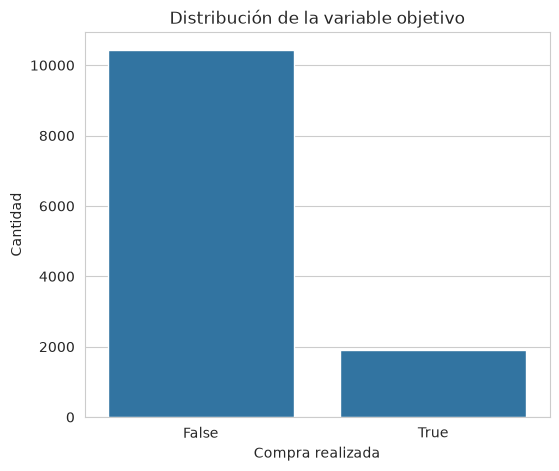

In [12]:
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x="Revenue")
plt.title("Distribución de la variable objetivo")
plt.xlabel("Compra realizada")
plt.ylabel("Cantidad")
plt.show()

La clase minoritaria (`Revenue = True`) representa una fracción reducida del dataset. Este desbalance deberá considerarse al elegir métricas y estrategias de entrenamiento del modelo.

## 4. Variables numéricas y categóricas

In [13]:
numerical_columns = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
]

categorical_columns = [
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType",
    "Weekend",
    "SpecialDay",
]

> **Nota:** `SpecialDay` se agrupa aquí junto a las variables categóricas porque toma pocos valores discretos (0, 0.2, 0.4, 0.6, 0.8, 1.0) y un `countplot` es más informativo que un histograma para visualizarla. En `src/preprocessing.py` (`COLUMNAS_NUMERICAS`), en cambio, se trata como numérica continua acotada en [0, 1] para la detección de outliers (IQR) y el escalado del pipeline de modelado. Es una elección de representación distinta según el propósito (EDA visual vs. pipeline numérico), no una inconsistencia entre notebooks.

### Distribución de variables numéricas

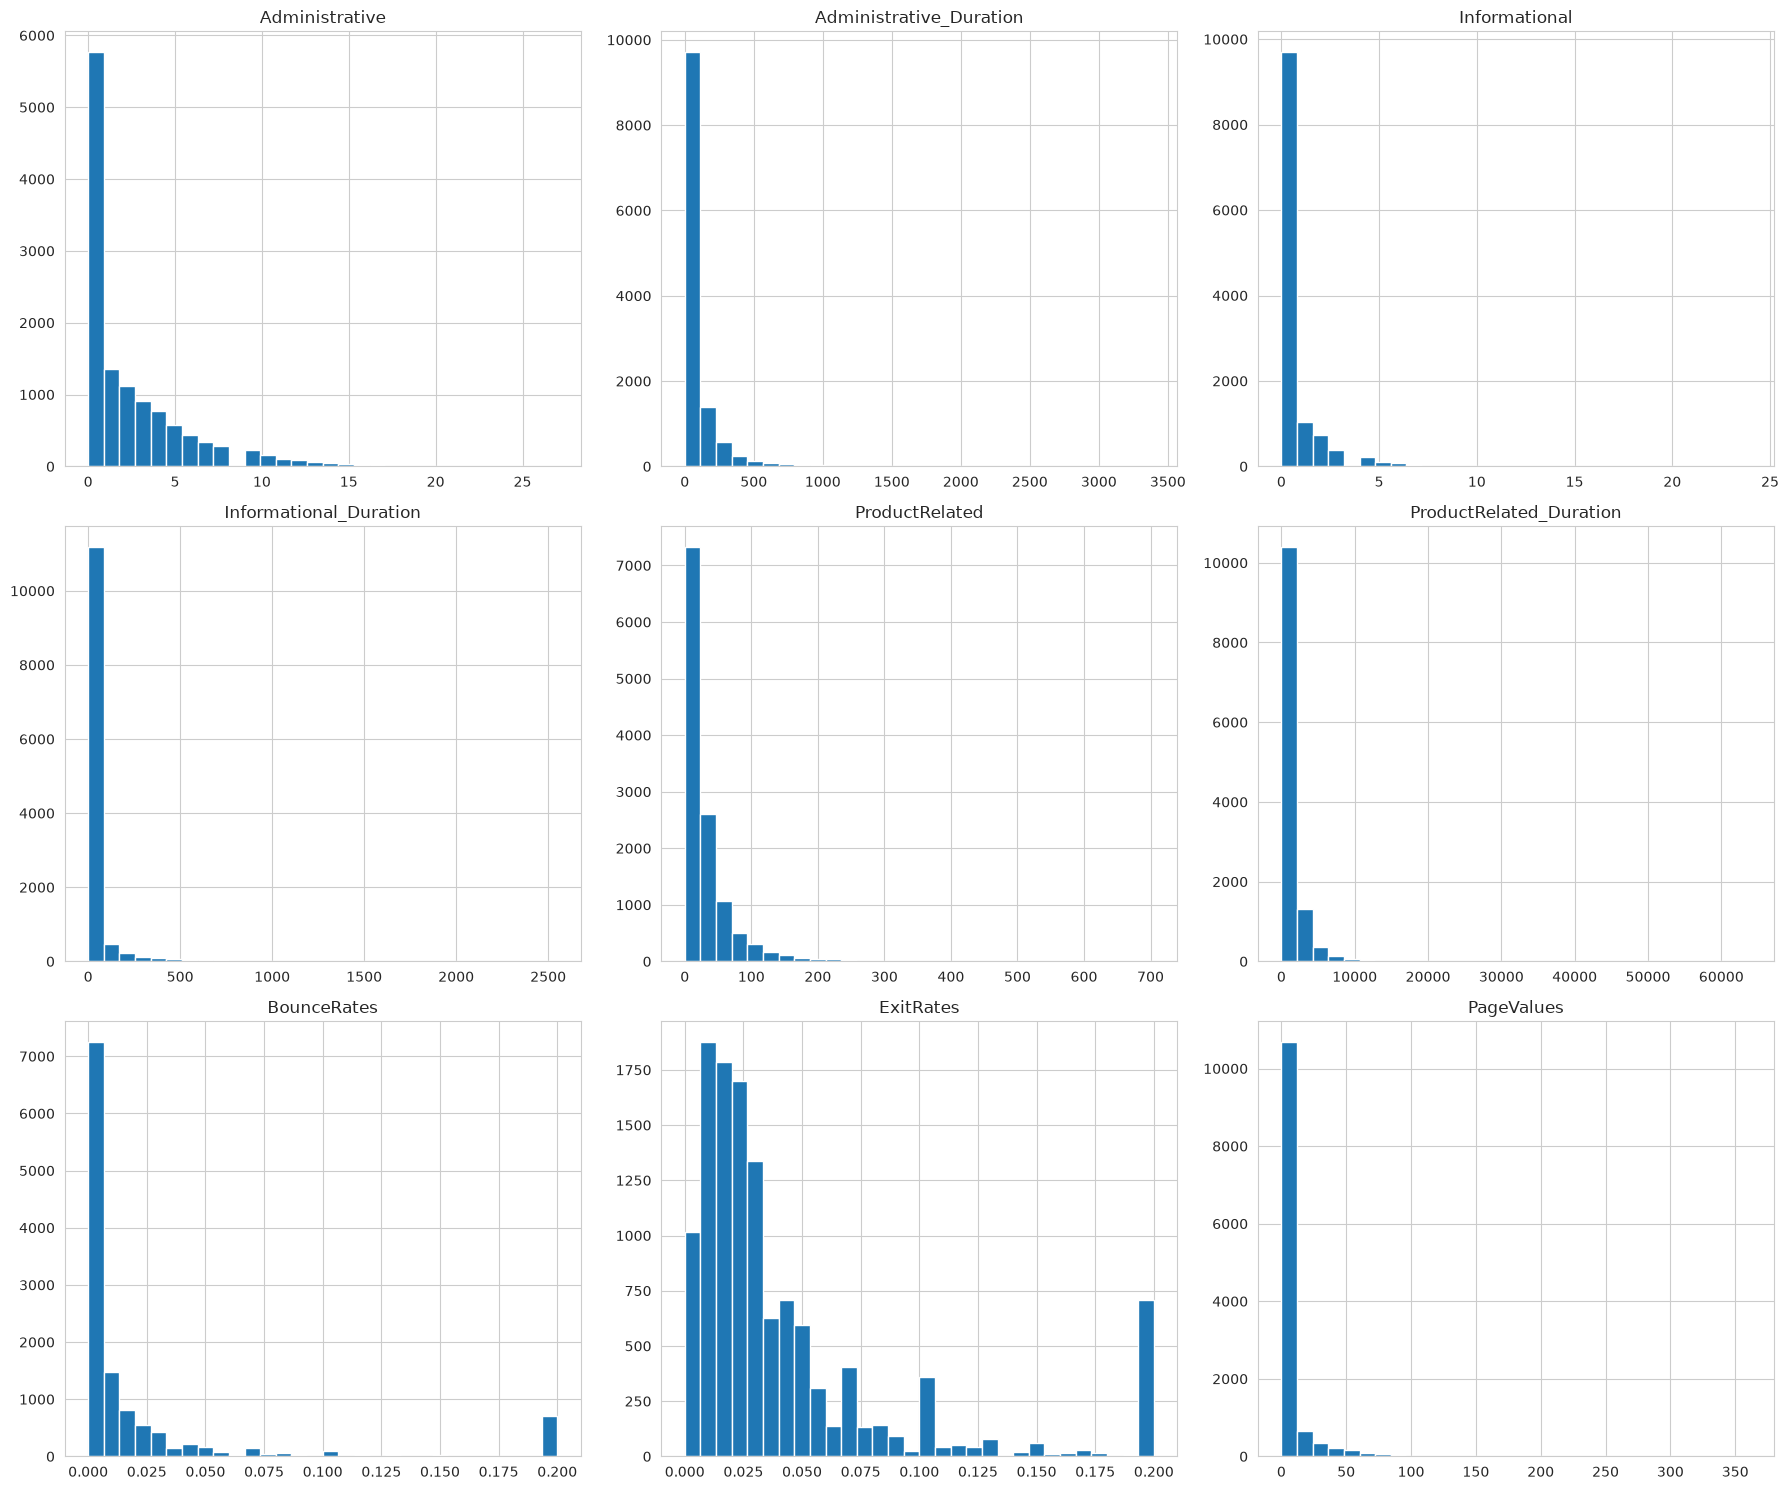

In [14]:
df[numerical_columns].hist(figsize=(18, 15), bins=30)
plt.tight_layout()
plt.show()

### Distribución de variables categóricas

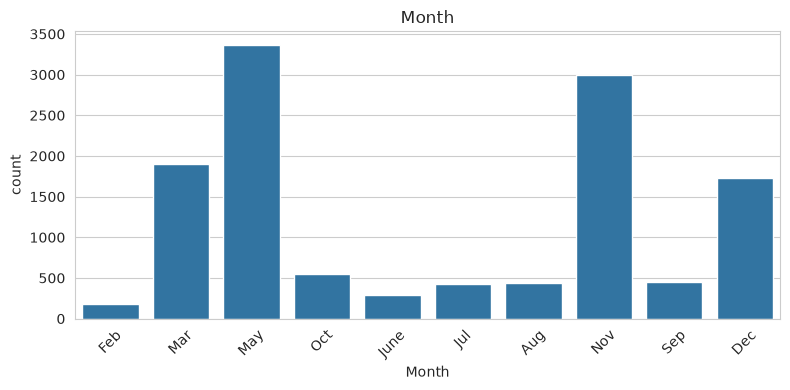

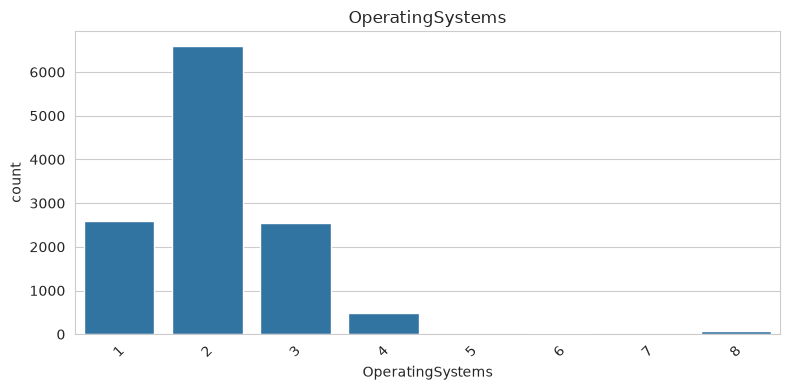

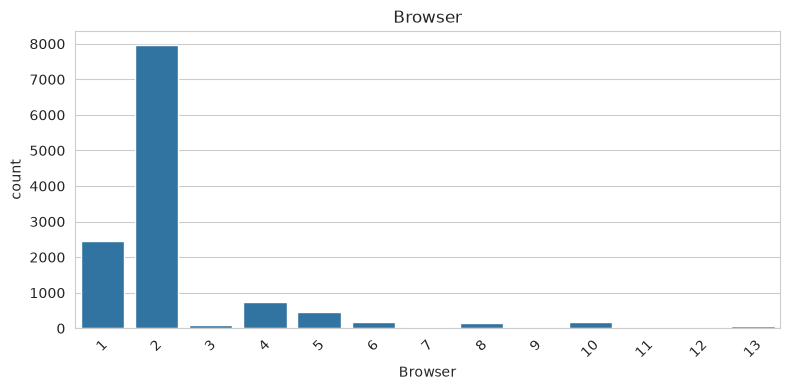

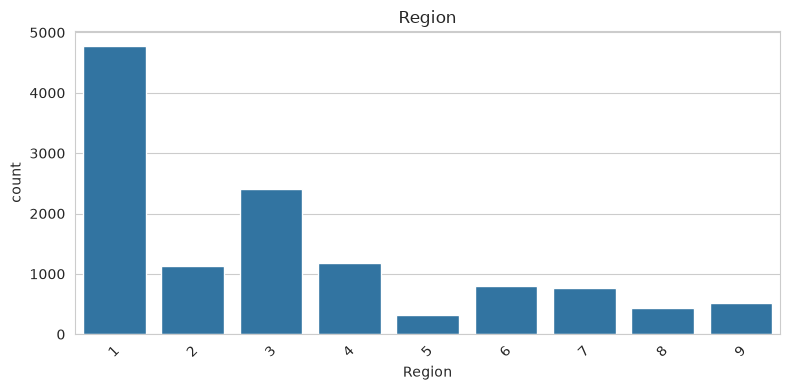

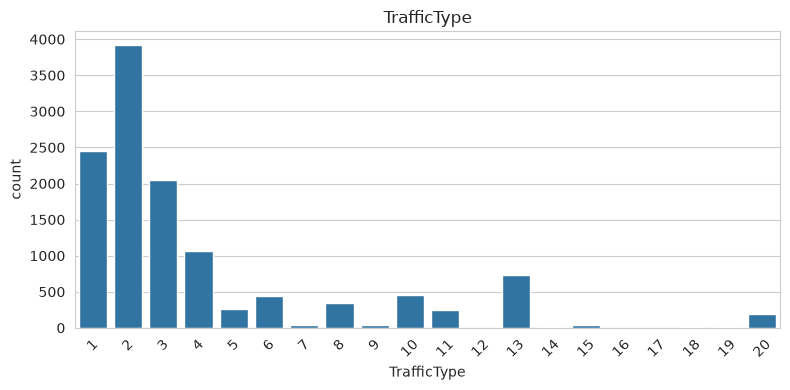

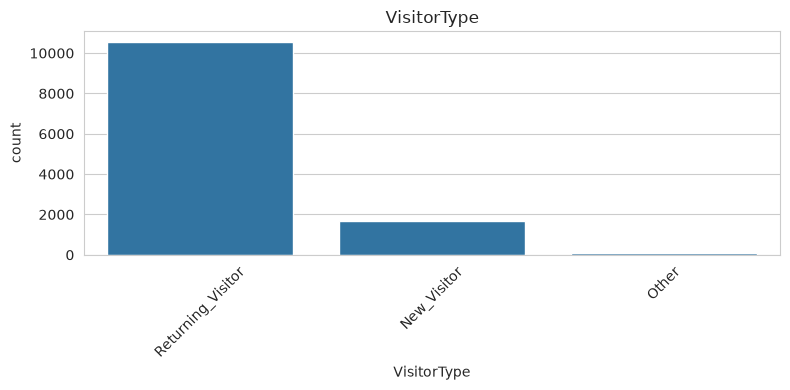

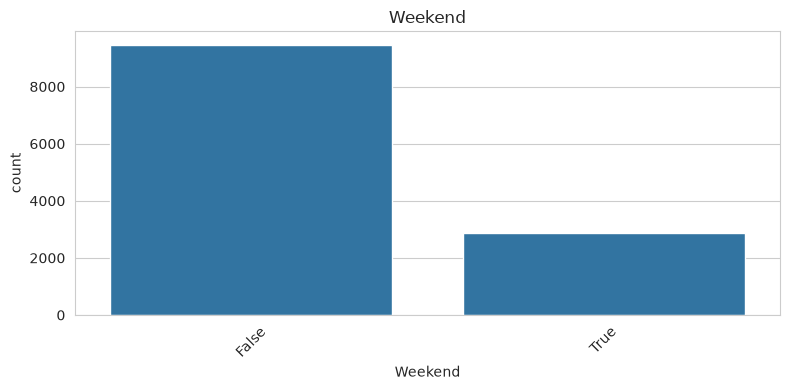

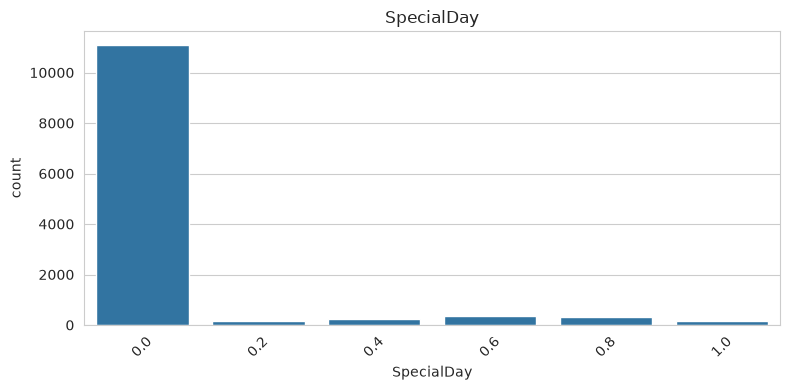

In [15]:
for column in categorical_columns:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=column)
    plt.title(column)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 5. Análisis univariado y outliers

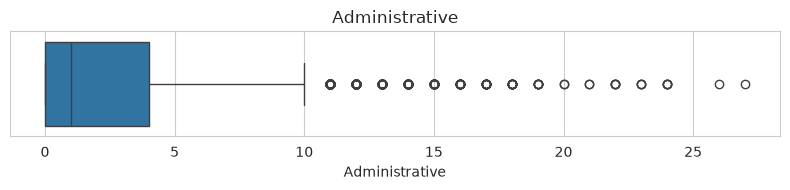

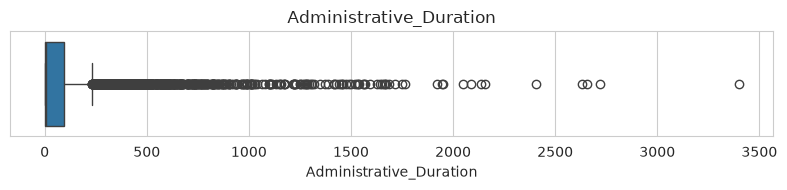

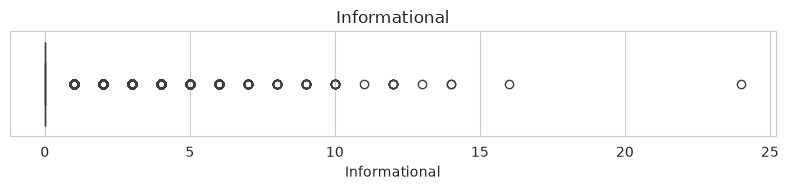

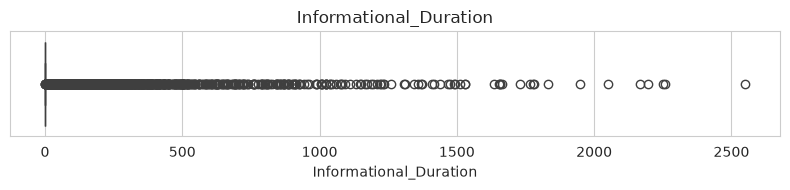

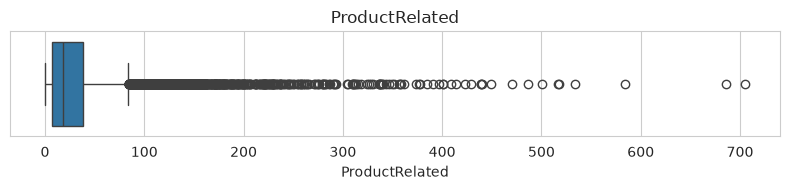

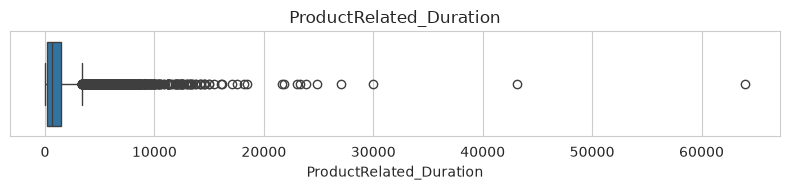

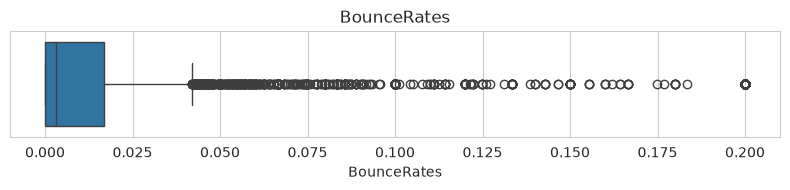

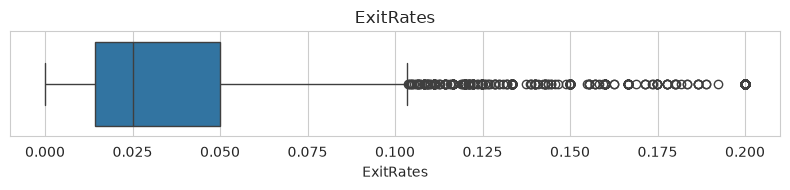

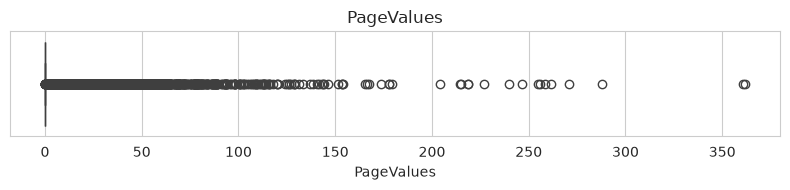

In [16]:
for column in numerical_columns:
    plt.figure(figsize=(8, 2))
    sns.boxplot(x=df[column])
    plt.title(column)
    plt.tight_layout()
    plt.show()

In [17]:
for column in numerical_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    outliers = df[(df[column] < Q1 - 1.5 * IQR) | (df[column] > Q3 + 1.5 * IQR)]

    print(f"{column}: {len(outliers)} outliers ({len(outliers) / len(df) * 100:.2f}%)")

Administrative: 404 outliers (3.28%)
Administrative_Duration: 1172 outliers (9.51%)
Informational: 2631 outliers (21.34%)
Informational_Duration: 2405 outliers (19.51%)
ProductRelated: 987 outliers (8.00%)
ProductRelated_Duration: 961 outliers (7.79%)
BounceRates: 1551 outliers (12.58%)
ExitRates: 1099 outliers (8.91%)
PageValues: 2730 outliers (22.14%)


## 6. Análisis bivariado (vs `Revenue`)

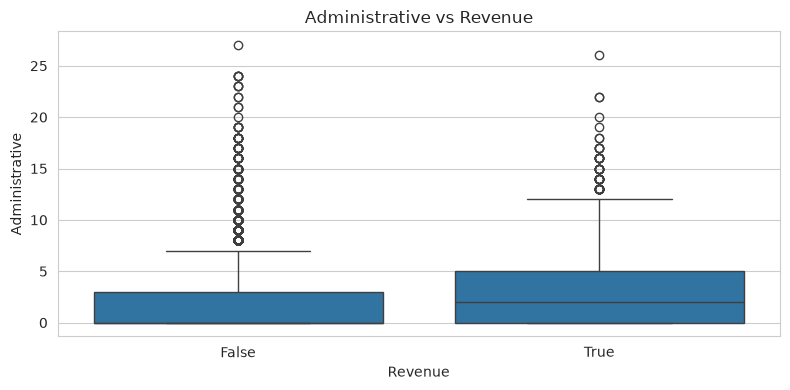

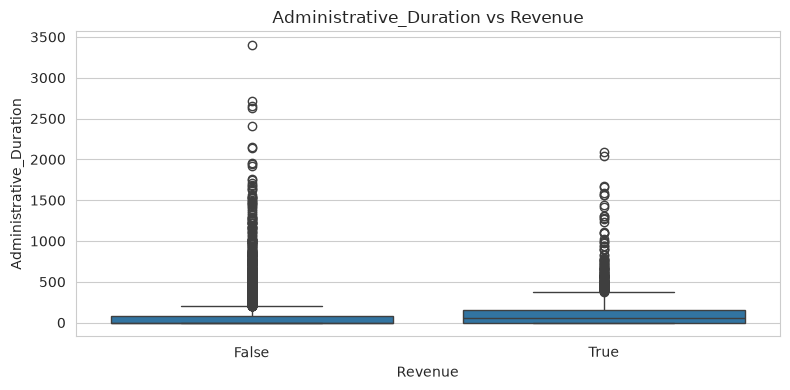

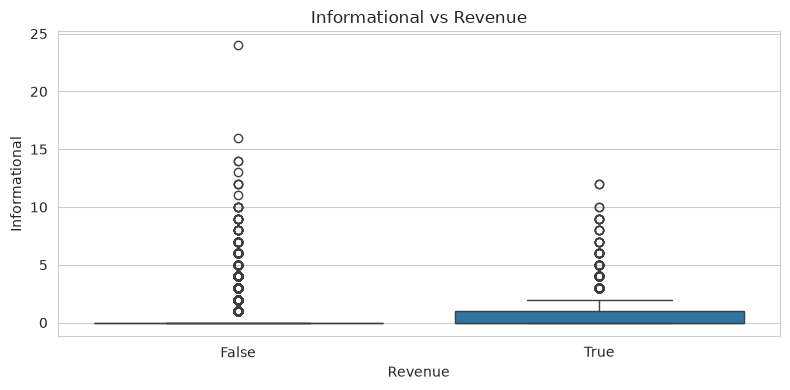

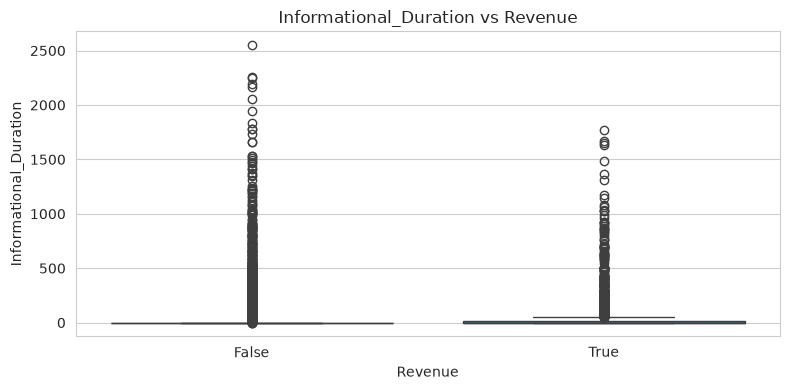

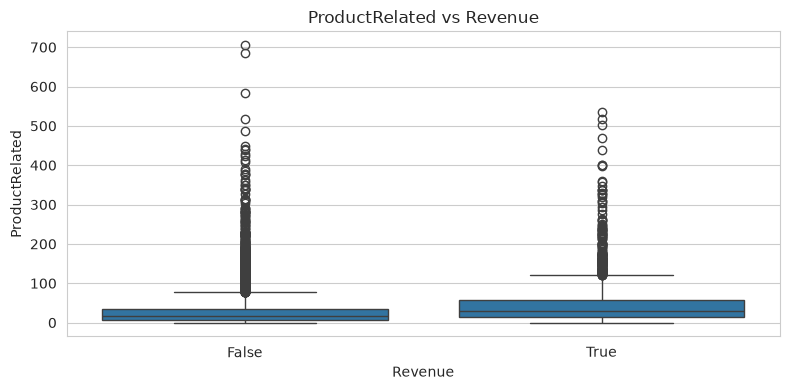

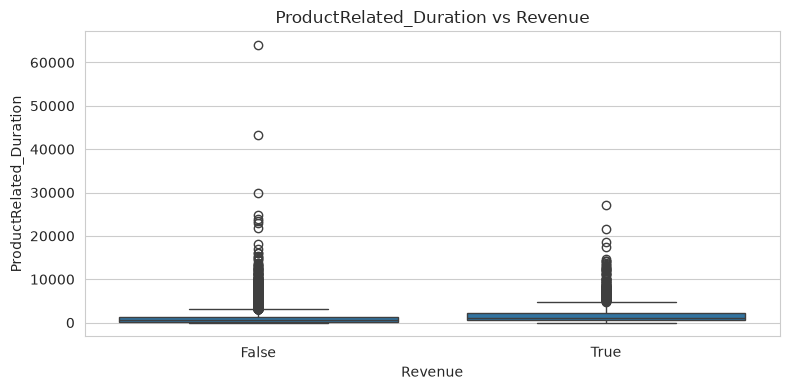

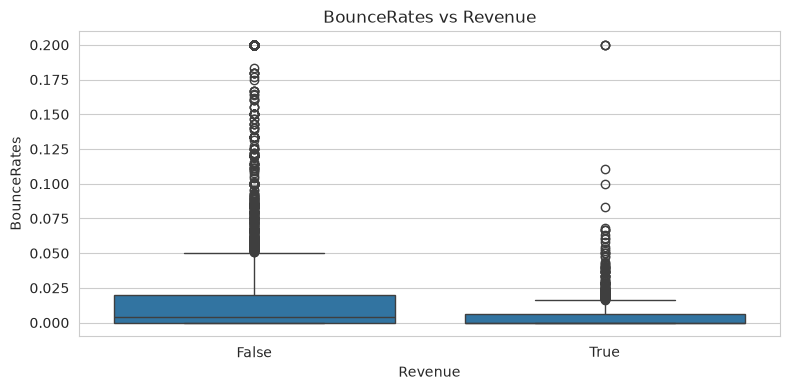

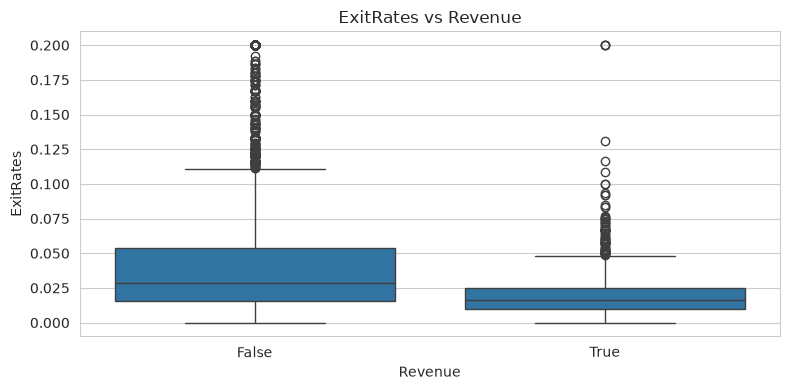

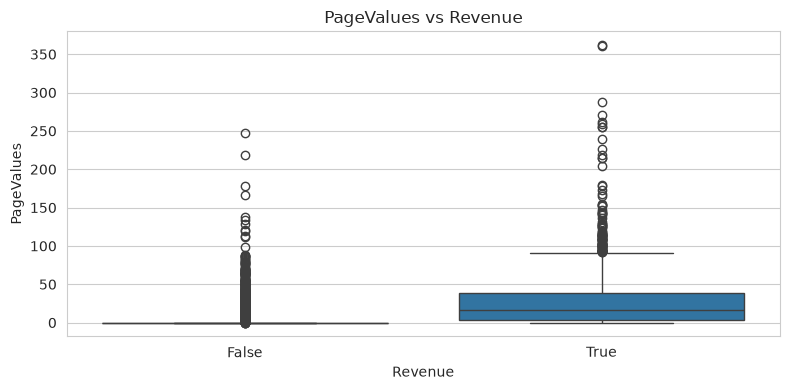

In [18]:
# Variables numéricas vs Revenue
for column in numerical_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x="Revenue", y=column)
    plt.title(f"{column} vs Revenue")
    plt.tight_layout()
    plt.show()

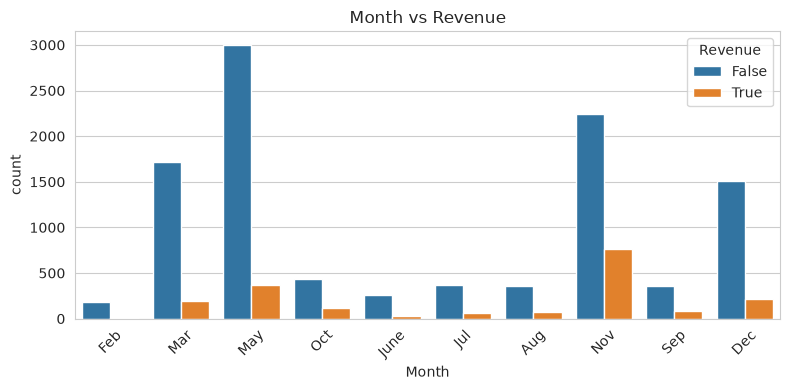

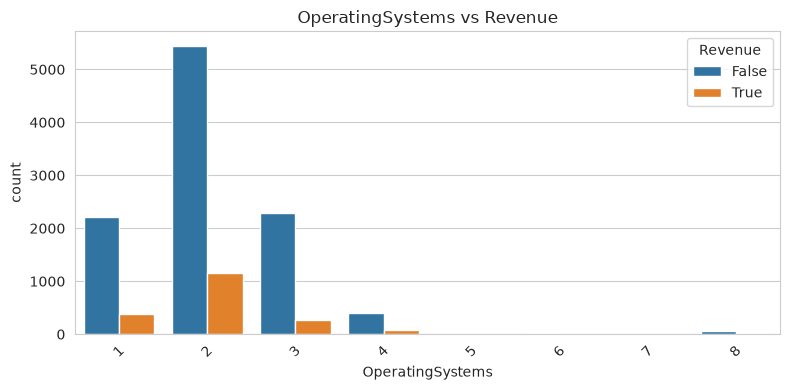

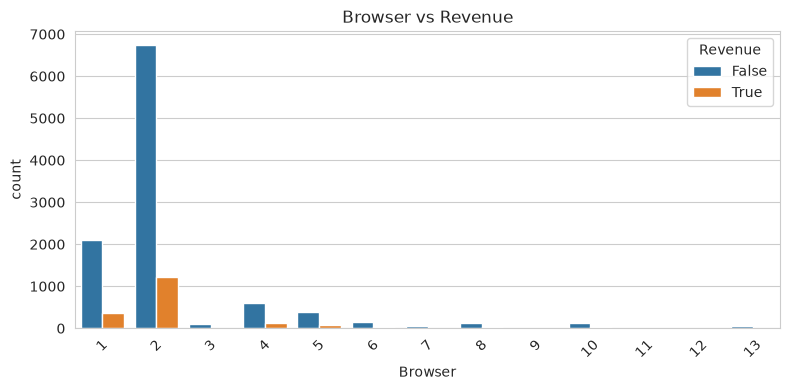

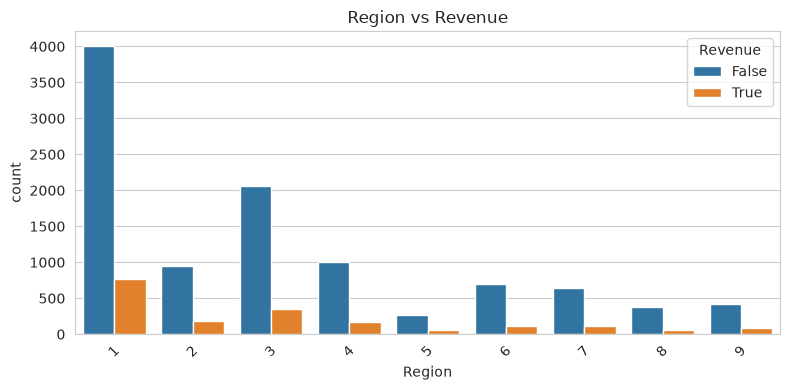

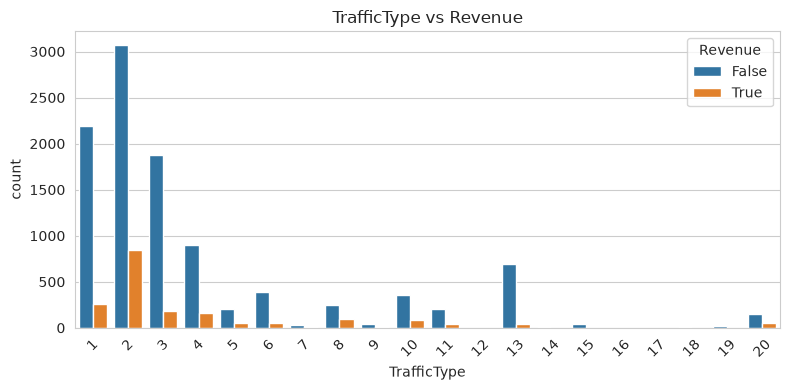

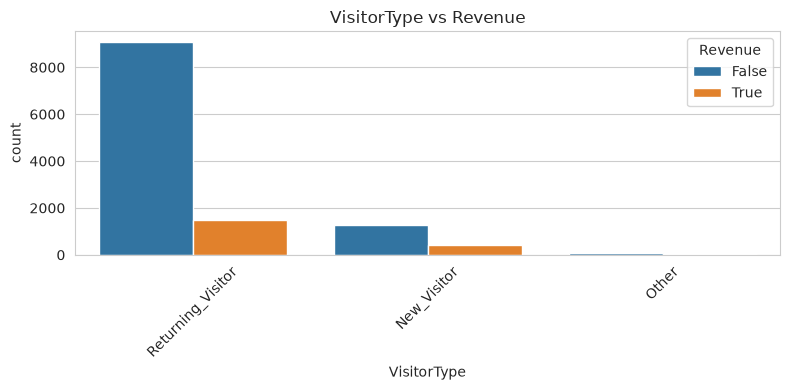

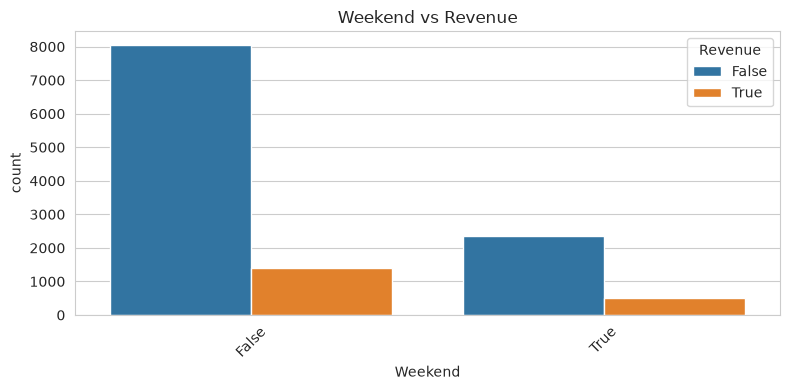

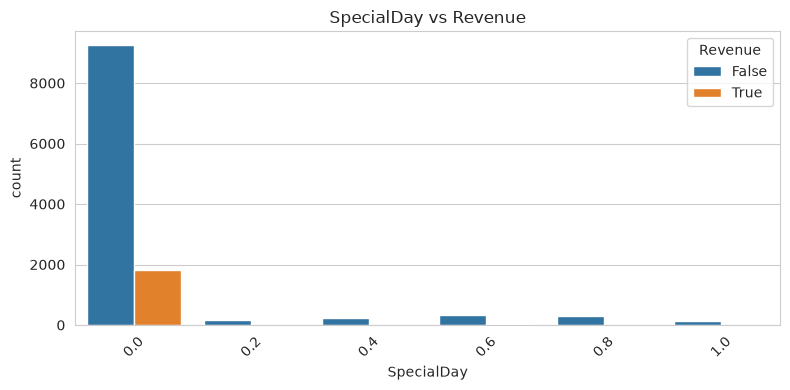

In [19]:
# Variables categóricas vs Revenue
for column in categorical_columns:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=column, hue="Revenue")
    plt.title(f"{column} vs Revenue")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 7. Correlaciones

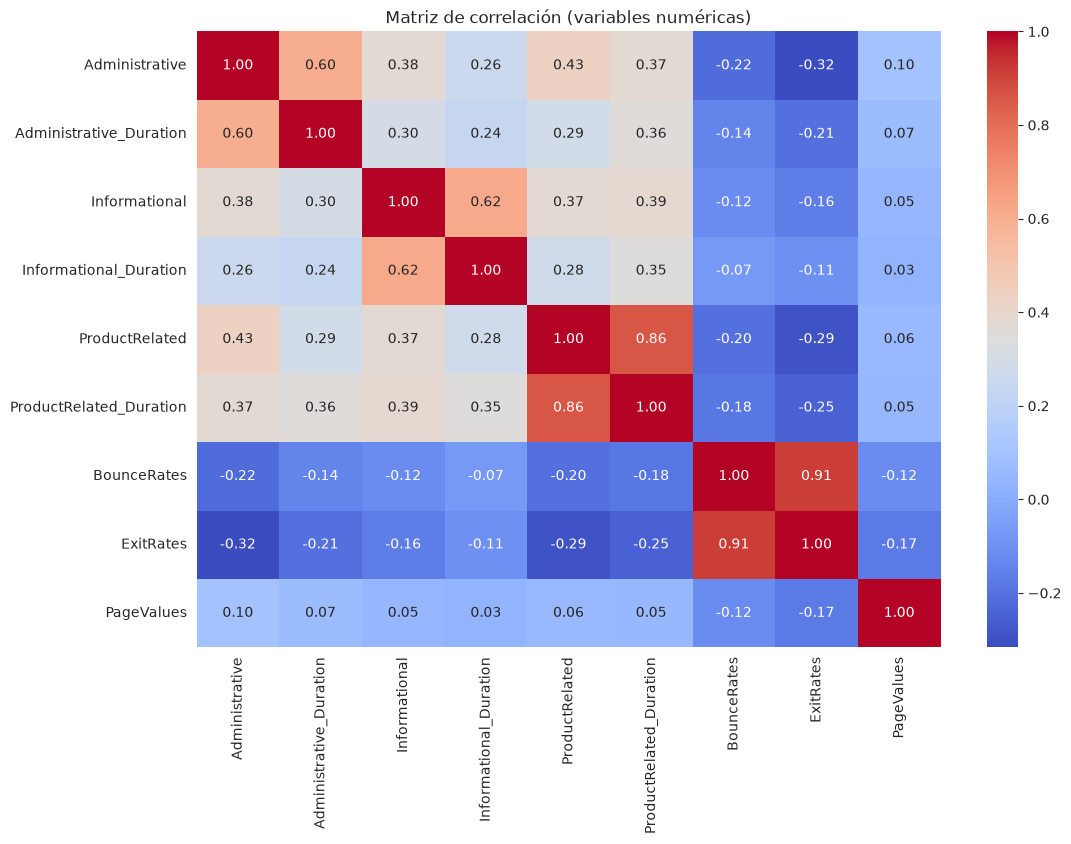

In [20]:
correlation = df[numerical_columns].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación (variables numéricas)")
plt.show()

### Correlación de todas las variables (incluyendo categóricas codificadas) con `Revenue`

Codificamos las variables categóricas con `pd.get_dummies` únicamente para poder incluirlas en el análisis de correlación con la variable objetivo (no se usa para modelado en este notebook).

In [21]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded["Revenue"] = df_encoded["Revenue"].astype(int)

correlation_target = (
    df_encoded.corr()["Revenue"]
    .drop("Revenue")
    .sort_values(key=abs, ascending=False)
)

correlation_target.head(15)

PageValues                       0.492569
ExitRates                       -0.207071
ProductRelated                   0.158538
Month_Nov                        0.154774
ProductRelated_Duration          0.152373
BounceRates                     -0.150673
Administrative                   0.138917
VisitorType_Returning_Visitor   -0.103843
Informational                    0.095200
Administrative_Duration          0.093587
SpecialDay                      -0.082305
Month_May                       -0.078320
Informational_Duration           0.070345
Month_Mar                       -0.063941
Month_Feb                       -0.047114
Name: Revenue, dtype: float64

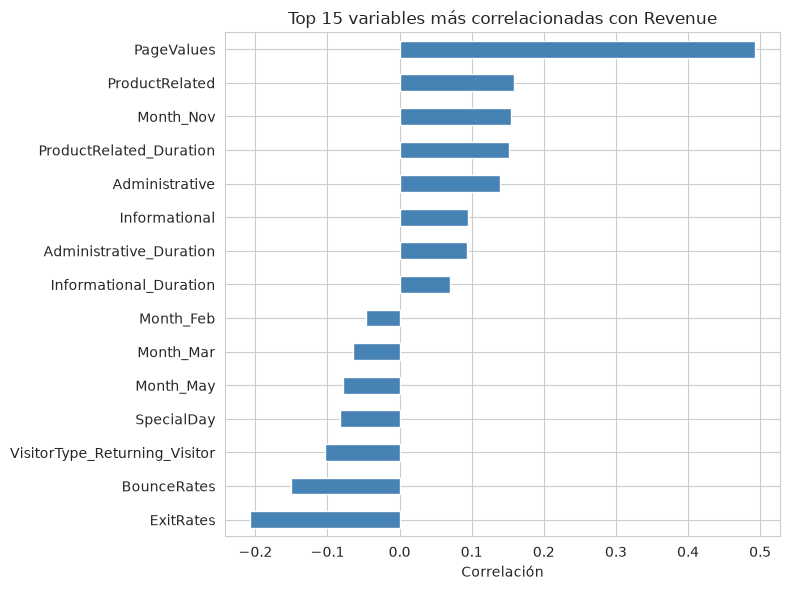

In [22]:
plt.figure(figsize=(8, 6))
correlation_target.head(15).sort_values().plot(kind="barh", color="steelblue")
plt.title("Top 15 variables más correlacionadas con Revenue")
plt.xlabel("Correlación")
plt.tight_layout()
plt.show()

## 8. Conclusiones del EDA

A partir del Análisis Exploratorio de Datos realizado sobre el dataset **Online Shoppers Purchasing Intention**, se obtuvieron los siguientes hallazgos:

- El conjunto de datos está compuesto por **12.330 registros** y **18 variables**, proporcionando una base de información adecuada para el desarrollo de un modelo de clasificación orientado a predecir la intención de compra de los usuarios.
- No se identificaron **valores faltantes**, por lo que no será necesario realizar procesos de imputación durante la etapa de preprocesamiento.
- Se detectaron registros **duplicados** (~1% del dataset). Debido a que cada fila representa una sesión de navegación y no existe un identificador único de usuario, estos registros no se eliminan automáticamente en el EDA, ya que podrían corresponder a sesiones distintas con características similares.
- La variable objetivo **Revenue** presenta un **desbalance de clases** marcado (~85% no compra vs ~15% compra). Este comportamiento deberá considerarse durante el entrenamiento de los modelos y la selección de métricas de evaluación (por ejemplo, priorizar precision/recall/F1 sobre accuracy).
- El análisis de las variables numéricas mostró distribuciones fuertemente sesgadas y la presencia de valores atípicos en varias de ellas (destacan `PageValues`, `Informational` e `Informational_Duration`). Estos valores no se eliminan automáticamente, ya que pueden representar comportamientos reales de navegación y contener información relevante para la predicción.
- Las variables categóricas permitieron identificar diferentes perfiles de usuarios y características de las sesiones (mes, tipo de visitante, fin de semana), aportando información complementaria para el modelo.
- El análisis bivariado y las matrices de correlación (numérica y con variables categóricas codificadas) muestran que `PageValues`, `ExitRates`, `BounceRates` y `ProductRelated_Duration` están entre las variables más asociadas con `Revenue`, proporcionando una base sólida para la selección de características en las siguientes etapas del proyecto (`02_feature_engineering.ipynb`).